In [1]:
import pandas as pd 
import numpy as np

In [2]:
df_raw=pd.read_csv("./CAMPUSX/DATASETS/placement.csv")
df=df_raw.copy()
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.shape

(100, 4)

Steps
e. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:

import matplotlib.pyplot as plt

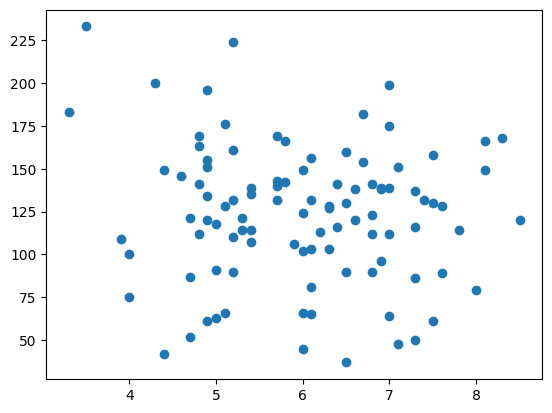

In [11]:
plt.scatter(df['cgpa'], df['iq'])

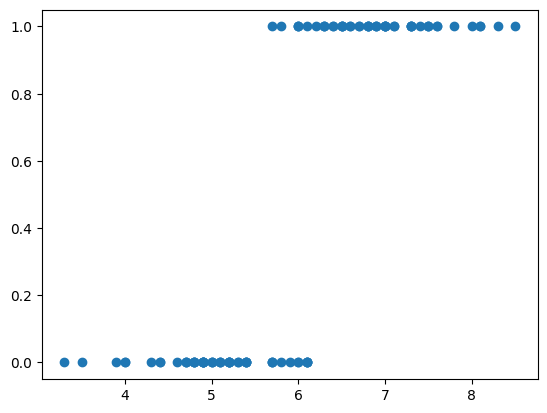

In [12]:
plt.scatter(df['cgpa'],df['placement'])

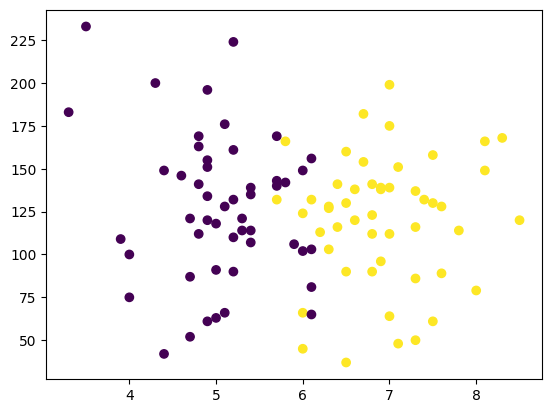

In [13]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [14]:
df['cgpa'].corr(df['iq'])

np.float64(-0.09879067205821165)

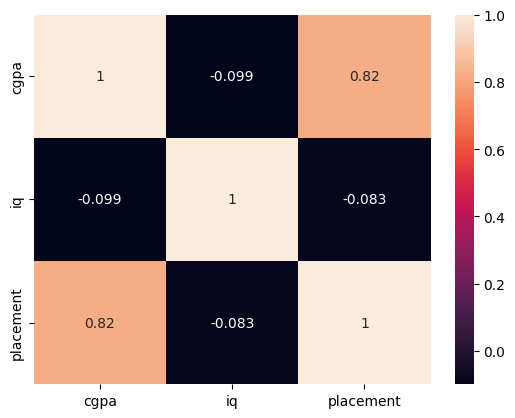

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[['cgpa', 'iq', 'placement']].corr(), annot=True)
plt.show()

corr(cgpa, placement) = 0.82 What this means

Strong positive correlation

Very close to +1

Interpretation

Higher CGPA strongly increases the chance of placement.

In real terms:

Students with higher CGPA are much more likely to be placed

CGPA is a very powerful predictor

corr(iq, placement) = -0.083 What this means

Very close to 0

Slight negative, but meaningless

Interpretation

IQ alone does NOT decide placement.

In real terms:

High IQ does not guarantee placement
Low IQ does not prevent placement

IQ might help only in combination, not alone

The correlation matrix shows that CGPA has a strong positive linear relationship with placement, making it a key predictor. IQ shows little linear correlation with either CGPA or placement, suggesting it does not independently determine outcomes but may still contribute in combination with other features.


 ------- Extract input and output cols

In [16]:
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

------Train test split

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=  train_test_split(X,Y,test_size = 0.10)
x_train

,cgpa,iq
34,4.8,163.0
48,6.6,138.0
6,5.7,143.0
18,4.0,100.0
83,7.5,130.0
...,...,...
98,6.3,103.0
91,7.5,158.0
51,4.8,141.0
42,7.6,89.0


In [19]:
y_train

34    0
48    1
6     0
18    0
83    1
     ..
98    1
91    1
51    0
42    1
88    0
Name: placement, Length: 90, dtype: int64

In [20]:
y_test

78    0
10    1
93    1
61    1
50    0
54    1
86    0
90    1
30    1
46    0
Name: placement, dtype: int64

In [21]:
x_test

,cgpa,iq
78,6.1,81.0
10,6.0,45.0
93,6.8,112.0
61,7.3,137.0
50,3.5,233.0
54,6.4,141.0
86,5.1,128.0
90,7.3,86.0
30,7.6,128.0
46,5.3,114.0


-----Scaling the data

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_train

array([[-1.03838206e+00,  1.00590955e+00],
       [ 5.53083347e-01,  3.62379129e-01],
       [-2.42649355e-01,  4.91085212e-01],
       [-1.74570001e+00, -6.15787106e-01],
       [ 1.34881605e+00,  1.56449395e-01],
       [ 4.64668603e-01,  9.28685896e-01],
       [ 9.06742326e-01, -3.06892506e-01],
       [ 6.41498092e-01,  1.49499266e+00],
       [ 2.25948792e-02,  6.45532512e-01],
       [-1.03838206e+00,  1.16035685e+00],
       [-1.83411476e+00, -3.84116156e-01],
       [ 9.06742326e-01,  3.88120345e-01],
       [ 2.05613401e+00,  1.13461563e+00],
       [-1.39204104e+00, -2.10877768e+00],
       [ 7.29912837e-01, -8.73199273e-01],
       [ 1.11009624e-01,  2.07931828e-01],
       [ 1.79088977e+00, -1.15635266e+00],
       [ 1.11009624e-01, -1.51672969e+00],
       [ 5.53083347e-01, -1.00962772e-01],
       [ 8.18327581e-01,  3.62379129e-01],
       [-2.42649355e-01,  1.16035685e+00],
       [ 6.41498092e-01,  7.74238596e-01],
       [-8.61552568e-01, -1.52445206e-01],
       [-9.

In [23]:
x_test = scaler.transform(x_test)

StandardScaler scales features by subtracting the mean and dividing by the standard deviation, so each feature has zero mean and unit variance. This ensures all features are on the same scale and prevents any one feature from dominating the model.

on what basis It uses statistics from the training data — the mean and standard deviation of each feature — and transforms values based on how far they are from the average.

We fit preprocessing steps only on training data to avoid data leakage. If test data statistics are used during fitting, information from the test set leaks into training, leading to overly optimistic and unrealistic model performance.

------Model training

In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
# model training
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

run this to get logisticRegression model

----Testing

In [26]:
y_pred=model.predict(x_test)
y_test

78    0
10    1
93    1
61    1
50    0
54    1
86    0
90    1
30    1
46    0
Name: placement, dtype: int64

----Calculating accuracy score

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9

In [28]:
print(y_train.value_counts())
print(y_test.value_counts())

placement
0    46
1    44
Name: count, dtype: int64
placement
1    6
0    4
Name: count, dtype: int64


In [29]:
from sklearn.metrics import accuracy_score

print("Train acc:", accuracy_score(y_train, model.predict(x_train)))
print("Test acc :", accuracy_score(y_test, model.predict(x_test)))

Train acc: 0.9333333333333333
Test acc : 0.9


In [34]:
!pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)


<Axes: >

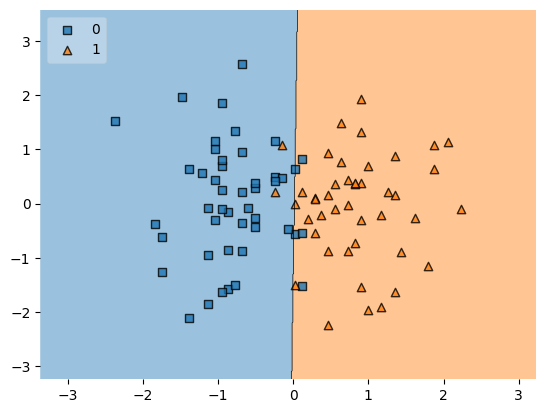

In [35]:
from mlxtend.plotting import plot_decision_regions

# x_train is already a numpy array, so no need for .values
# the model variable you trained is called 'model'
# the parameter name is 'clf'
plot_decision_regions(x_train, y_train.values, clf=model, legend=2)

----Deploy the model

In [30]:
import pickle

In [31]:

pickle.dump(model,open('model.pkl','wb'))

now deploy the model and integrate with a website to get output website